In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import colors
from copy import deepcopy

from rashomon import hasse, counter

%matplotlib inline

## Setup: Load Data

In [2]:
# Define profiles and best profile
profiles, profiles_map = hasse.enumerate_profiles(4)
profile_cols = [str(x) for x in profiles]
best_profile = (1, 0, 1, 0)
best_profile_idx = profiles_map[best_profile]
true_best_profile = str(best_profile)

print(f"True best profile: {true_best_profile}")
print(f"Profile index: {best_profile_idx}")
print(f"Total profiles: {len(profile_cols)}")

True best profile: (1, 0, 1, 0)
Profile index: 10
Total profiles: 16


In [3]:
# File configuration
fname_prefix = "4arms_"
fname_suffix = "_30_100.csv"

rashomon_fname = f"../Results/4arms/{fname_prefix}rashomon{fname_suffix}"
blasso_fname = f"../Results/4arms/{fname_prefix}blasso_samples{fname_suffix}"
ssl_fname = f"../Results/4arms/{fname_prefix}ssl{fname_suffix}"
bootstrap_fname = f"../Results/4arms/{fname_prefix}bootstrap{fname_suffix}"
bootstrap_samples_fname = f"../Results/4arms/{fname_prefix}bootstrap_samples{fname_suffix}"

In [4]:
# Load Rashomon
rashomon_df = pd.read_csv(rashomon_fname).drop("Unnamed: 0", axis=1)
print(f"Rashomon: {len(rashomon_df)} models")

# Load Bayesian Lasso (samples)
blasso_df = pd.read_csv(blasso_fname).drop("Unnamed: 0", axis=1)
print(f"Bayesian Lasso: {len(blasso_df)} samples")

# Load Spike-Slab Lasso (samples)
ssl_df = pd.read_csv(ssl_fname).drop("Unnamed: 0", axis=1)
print(f"Spike-Slab Lasso: {len(ssl_df)} samples")

# Load Bootstrap (samples)
bootstrap_df = pd.read_csv(bootstrap_fname).drop("Unnamed: 0", axis=1)
bootstrap_samples_df = pd.read_csv(bootstrap_samples_fname).drop("Unnamed: 0", axis=1)
print(f"Bootstrap: {len(bootstrap_df)} summary, {len(bootstrap_samples_df)} samples")

Rashomon: 203940 models
Bayesian Lasso: 450000 samples
Bayesian Lasso: 450000 samples
Spike-Slab Lasso: 440000 samples
Spike-Slab Lasso: 440000 samples
Bootstrap: 100 summary, 100000 samples
Bootstrap: 100 summary, 100000 samples


In [5]:
def compute_prob(df, neg_log_posterior_col='neg_log_posterior'):
    """
    Compute binary presence in HPD region.
    Returns: fraction of simulations where profile appears at least once in HPD.
    """
    df_copy = df.copy()
    
    # Convert to log posterior and normalize
    df_copy['log_posterior'] = -df_copy[neg_log_posterior_col]
    df_copy['log_posterior_normalized'] = df_copy.groupby(['n_per_pol', 'sim_num'])['log_posterior'].transform(
        lambda x: x - x.max()
    )
    
    # Compute posterior weights
    df_copy['posterior_weight'] = np.exp(df_copy['log_posterior_normalized'])
    df_copy['posterior_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])['posterior_weight'].transform(
        lambda x: x / x.sum()
    )
    
    # Sort by weight within each simulation (descending)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', 'posterior_weight'], ascending=[True, True, False])

    return df_copy

In [6]:
# Compute posterior for Rashomon
lambda_rashomon = 1e-1
rashomon_df['neg_log_posterior'] = rashomon_df['MSE'] + lambda_rashomon * rashomon_df['num_pools']
rashomon_df = compute_prob(rashomon_df)

# Compute posterior for other methods
blasso_df = compute_prob(blasso_df)
ssl_df = compute_prob(ssl_df)
bootstrap_samples_df = compute_prob(bootstrap_samples_df, neg_log_posterior_col='penalized_loss')

## 1. HPD-Based Analysis (Fair Comparison to Rashomon)

For a fair comparison:
- **Rashomon**: Models within ε% of optimal (near-MAP region)
- **Bayesian methods**: Highest Posterior Density (HPD) region (e.g., 95% credible set)
- **Bootstrap**: Top models by penalized loss

This compares "high-quality model sets" across all methods.

In [7]:
def compute_frequency_inclusion(df, profile_col, group_cols=['n_per_pol', 'sim_num']):
    """
    Compute frequency-based inclusion rate.
    Returns: fraction of samples in each simulation that have the true best profile.
    """
    df_copy = df.copy()
    df_copy['has_best_profile'] = (df_copy[profile_col] > 0).astype(int)
    
    # Fraction per simulation
    freq_per_sim = df_copy.groupby(group_cols)['has_best_profile'].mean().reset_index()
    freq_per_sim.rename(columns={'has_best_profile': 'frequency_inclusion'}, inplace=True)
    
    # Overall mean
    overall_freq = freq_per_sim['frequency_inclusion'].mean()
    
    return freq_per_sim, overall_freq

def compute_hpd_frequency(df, profile_col, credible_mass=0.95, neg_log_posterior_col='neg_log_posterior'):
    """
    Compute frequency in Highest Posterior Density (HPD) region.
    
    Args:
        df: DataFrame with samples
        profile_col: Column name for the profile to check
        credible_mass: Fraction of posterior mass to include (default 0.95)
        neg_log_posterior_col: Column with negative log posterior values
    
    Returns:
        freq_per_sim: DataFrame with HPD frequency per simulation
        overall_freq: Mean HPD frequency across simulations
        hpd_size_per_sim: DataFrame with number of samples in HPD per simulation
    """
    df_copy = df.copy()
    
    # Convert to log posterior and normalize
    df_copy['log_posterior'] = -df_copy[neg_log_posterior_col]
    df_copy['log_posterior_normalized'] = df_copy.groupby(['n_per_pol', 'sim_num'])['log_posterior'].transform(
        lambda x: x - x.max()
    )
    
    # Compute posterior weights
    df_copy['posterior_weight'] = np.exp(df_copy['log_posterior_normalized'])
    df_copy['posterior_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])['posterior_weight'].transform(
        lambda x: x / x.sum()
    )
    
    # Sort by weight within each simulation (descending)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', 'posterior_weight'], ascending=[True, True, False])
    
    # Cumulative weight
    df_copy['cumsum_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])['posterior_weight'].cumsum()
    
    # Keep only samples in HPD region
    hpd_samples = df_copy[df_copy['cumsum_weight'] <= credible_mass].copy()
    
    # Frequency within HPD region
    hpd_samples['has_best_profile'] = (hpd_samples[profile_col] > 0).astype(int)
    freq_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].mean().reset_index()
    freq_per_sim.rename(columns={'has_best_profile': 'hpd_frequency'}, inplace=True)
    
    # Count samples in HPD region per simulation
    hpd_size_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='hpd_size')
    
    overall_freq = freq_per_sim['hpd_frequency'].mean()
    
    return freq_per_sim, overall_freq, hpd_size_per_sim

def compute_top_k_frequency(df, profile_col, loss_col, k_fraction=0.95):
    """
    Compute frequency in top-K models by loss.
    For Bootstrap: use penalized loss to define "top models".
    
    Args:
        df: DataFrame with samples
        profile_col: Column name for the profile to check
        loss_col: Column with loss values (lower is better)
        k_fraction: Fraction of models to include (default 0.95)
    
    Returns:
        freq_per_sim: DataFrame with top-K frequency per simulation
        overall_freq: Mean top-K frequency across simulations
    """
    df_copy = df.copy()
    
    # Sort by loss within each simulation (ascending - lower loss is better)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', loss_col], ascending=[True, True, True])
    
    # Assign rank
    df_copy['rank'] = df_copy.groupby(['n_per_pol', 'sim_num']).cumcount()
    
    # Determine K for each simulation
    total_per_sim = df_copy.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='total')
    total_per_sim['k_threshold'] = (total_per_sim['total'] * k_fraction).astype(int)
    
    # Merge back
    df_copy = df_copy.merge(total_per_sim[['n_per_pol', 'sim_num', 'k_threshold']], on=['n_per_pol', 'sim_num'])
    
    # Keep only top-K
    top_k_samples = df_copy[df_copy['rank'] < df_copy['k_threshold']].copy()
    
    # Frequency within top-K
    top_k_samples['has_best_profile'] = (top_k_samples[profile_col] > 0).astype(int)
    freq_per_sim = top_k_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].mean().reset_index()
    freq_per_sim.rename(columns={'has_best_profile': 'topk_frequency'}, inplace=True)
    
    overall_freq = freq_per_sim['topk_frequency'].mean()
    
    return freq_per_sim, overall_freq

In [8]:
def compute_hpd_frequency2(df, profile_col, credible_mass=0.95, posterior_weight_col='posterior_weight'):
    """
    Compute frequency in Highest Posterior Density (HPD) region.
    
    Args:
        df: DataFrame with samples
        profile_col: Column name for the profile to check
        credible_mass: Fraction of posterior mass to include (default 0.95)
        neg_log_posterior_col: Column with negative log posterior values
    
    Returns:
        freq_per_sim: DataFrame with HPD frequency per simulation
        overall_freq: Mean HPD frequency across simulations
        hpd_size_per_sim: DataFrame with number of samples in HPD per simulation
    """
    df_copy = df.copy()
    
    # Sort by weight within each simulation (descending)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', posterior_weight_col], ascending=[True, True, False])
    
    # Cumulative weight
    df_copy['cumsum_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])[posterior_weight_col].cumsum()
    
    # Keep only samples in HPD region
    hpd_samples = df_copy[df_copy['cumsum_weight'] <= credible_mass].copy()

    # Count samples in HPD region per simulation
    hpd_size_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='hpd_size')

    # Frequency within HPD region
    hpd_samples['has_best_profile'] = (hpd_samples[profile_col] > 0).astype(int)
    freq_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].mean().reset_index()
    freq_per_sim.rename(columns={'has_best_profile': 'hpd_frequency'}, inplace=True)
    
    # Count samples in HPD region per simulation
    hpd_size_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='hpd_size')
    
    overall_freq = freq_per_sim['hpd_frequency'].mean()
    
    return freq_per_sim, overall_freq, hpd_size_per_sim, hpd_size_per_sim

a, b, c, d = compute_hpd_frequency2(ssl_df, profile_col=true_best_profile, credible_mass=0.8)
d

,n_per_pol,sim_num,hpd_size
0,30,98,1


In [9]:
# Compute HPD-based inclusion (fair comparison to Rashomon)
credible_mass = 0.95

print(f"Computing HPD regions with {credible_mass*100}% posterior mass...\n")

# Rashomon: Already an epsilon-ball (keep as-is)
rashomon_freq, rashomon_freq_mean = compute_frequency_inclusion(
    rashomon_df, true_best_profile
)

# Bayesian Lasso: 95% HPD region
blasso_hpd_freq, blasso_hpd_freq_mean, blasso_hpd_size = compute_hpd_frequency(
    blasso_df, true_best_profile, credible_mass=credible_mass
)

# SSL: 95% HPD region
ssl_hpd_freq, ssl_hpd_freq_mean, ssl_hpd_size = compute_hpd_frequency(
    ssl_df, true_best_profile, credible_mass=credible_mass
)

# Bootstrap: Top 95% by penalized loss
bootstrap_topk_freq, bootstrap_topk_freq_mean = compute_top_k_frequency(
    bootstrap_samples_df, true_best_profile, 'penalized_loss', k_fraction=credible_mass
)

print("HPD/Top-K Inclusion Rates (Fair Comparison):")
print(f"  Rashomon (ε-ball):        {rashomon_freq_mean:.3f}")
print(f"  Bayesian Lasso (95% HPD): {blasso_hpd_freq_mean:.3f}")
print(f"  SSL (95% HPD):            {ssl_hpd_freq_mean:.3f}")
print(f"  Bootstrap (top 95%):      {bootstrap_topk_freq_mean:.3f}")

print(f"\nMean HPD/Top-K region sizes:")
print(f"  Bayesian Lasso: {blasso_hpd_size['hpd_size'].mean():.1f} samples")
print(f"  SSL:            {ssl_hpd_size['hpd_size'].mean():.1f} samples")

Computing HPD regions with 95.0% posterior mass...

HPD/Top-K Inclusion Rates (Fair Comparison):
  Rashomon (ε-ball):        0.527
  Bayesian Lasso (95% HPD): 0.231
  SSL (95% HPD):            0.500
  Bootstrap (top 95%):      0.468

Mean HPD/Top-K region sizes:
  Bayesian Lasso: 1.4 samples
  SSL:            1.0 samples
HPD/Top-K Inclusion Rates (Fair Comparison):
  Rashomon (ε-ball):        0.527
  Bayesian Lasso (95% HPD): 0.231
  SSL (95% HPD):            0.500
  Bootstrap (top 95%):      0.468

Mean HPD/Top-K region sizes:
  Bayesian Lasso: 1.4 samples
  SSL:            1.0 samples


## 2. Binary Presence Analysis (At Least One)

Check if the true best profile appears **at least once** in each region/set (binary: yes/no).

In [10]:
def compute_binary_presence(df, profile_col, group_cols=['n_per_pol', 'sim_num']):
    """
    Compute binary presence: does the true best profile appear at least once?
    Returns: fraction of simulations where profile appears at least once (0 or 1 per simulation).
    """
    df_copy = df.copy()
    df_copy['has_best_profile'] = (df_copy[profile_col] > 0).astype(int)
    
    # Check if ANY sample in each simulation has the profile
    presence_per_sim = df_copy.groupby(group_cols)['has_best_profile'].max().reset_index()
    presence_per_sim.rename(columns={'has_best_profile': 'binary_presence'}, inplace=True)
    
    # Overall mean (fraction of simulations with at least one)
    overall_presence = presence_per_sim['binary_presence'].mean()
    
    return presence_per_sim, overall_presence

def compute_hpd_binary_presence(df, profile_col, credible_mass=0.95, posterior_weight_col='posterior_weight'):
    """
    Compute binary presence in HPD region.
    Returns: fraction of simulations where profile appears at least once in HPD.
    """
    df_copy = df.copy()
    
    # Sort by weight within each simulation (descending)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', posterior_weight_col], ascending=[True, True, False])
    
    # Cumulative weight
    df_copy['cumsum_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])[posterior_weight_col].cumsum()
    
    # Keep only samples in HPD region
    hpd_samples = df_copy[df_copy['cumsum_weight'] <= credible_mass].copy()
    
    # Binary presence within HPD region
    hpd_samples['has_best_profile'] = (hpd_samples[profile_col] > 0).astype(int)
    presence_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].max().reset_index()
    presence_per_sim.rename(columns={'has_best_profile': 'hpd_binary_presence'}, inplace=True)
    
    overall_presence = presence_per_sim['hpd_binary_presence'].mean()
    
    return presence_per_sim, overall_presence

def compute_top_k_binary_presence(df, profile_col, loss_col, k_fraction=0.95):
    """
    Compute binary presence in top-K models.
    Returns: fraction of simulations where profile appears at least once in top-K.
    """
    df_copy = df.copy()
    
    # Sort by loss within each simulation (ascending - lower loss is better)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', loss_col], ascending=[True, True, True])
    
    # Assign rank
    df_copy['rank'] = df_copy.groupby(['n_per_pol', 'sim_num']).cumcount()
    
    # Determine K for each simulation
    total_per_sim = df_copy.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='total')
    total_per_sim['k_threshold'] = (total_per_sim['total'] * k_fraction).astype(int)
    
    # Merge back
    df_copy = df_copy.merge(total_per_sim[['n_per_pol', 'sim_num', 'k_threshold']], on=['n_per_pol', 'sim_num'])
    
    # Keep only top-K
    top_k_samples = df_copy[df_copy['rank'] < df_copy['k_threshold']].copy()
    
    # Binary presence within top-K
    top_k_samples['has_best_profile'] = (top_k_samples[profile_col] > 0).astype(int)
    presence_per_sim = top_k_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].max().reset_index()
    presence_per_sim.rename(columns={'has_best_profile': 'topk_binary_presence'}, inplace=True)
    
    overall_presence = presence_per_sim['topk_binary_presence'].mean()
    
    return presence_per_sim, overall_presence

In [11]:
# Compute binary presence for all methods

print("Computing binary presence (at least one occurrence)...\n")

# Rashomon: ε-ball
rashomon_presence, rashomon_presence_mean = compute_binary_presence(
    rashomon_df, true_best_profile
)

# Bayesian Lasso: 95% HPD region
blasso_hpd_presence, blasso_hpd_presence_mean = compute_hpd_binary_presence(
    blasso_df, true_best_profile, credible_mass=credible_mass
)

# Bayesian Lasso: Full posterior
blasso_full_presence, blasso_full_presence_mean = compute_binary_presence(
    blasso_df, true_best_profile
)

# SSL: 95% HPD region
ssl_hpd_presence, ssl_hpd_presence_mean = compute_hpd_binary_presence(
    ssl_df, true_best_profile, credible_mass=credible_mass
)

# SSL: Full posterior
ssl_full_presence, ssl_full_presence_mean = compute_binary_presence(
    ssl_df, true_best_profile
)

# Bootstrap: Top 95%
bootstrap_topk_presence, bootstrap_topk_presence_mean = compute_top_k_binary_presence(
    bootstrap_samples_df, true_best_profile, 'penalized_loss', k_fraction=credible_mass
)

# Bootstrap: All samples
bootstrap_full_presence, bootstrap_full_presence_mean = compute_binary_presence(
    bootstrap_samples_df, true_best_profile
)

print("Binary Presence - HPD/Top-K Region:")
print(f"  Rashomon (ε-ball):        {rashomon_presence_mean:.3f} ({rashomon_presence_mean*100:.1f}% of simulations)")
print(f"  Bayesian Lasso (95% HPD): {blasso_hpd_presence_mean:.3f} ({blasso_hpd_presence_mean*100:.1f}% of simulations)")
print(f"  SSL (95% HPD):            {ssl_hpd_presence_mean:.3f} ({ssl_hpd_presence_mean*100:.1f}% of simulations)")
print(f"  Bootstrap (top 95%):      {bootstrap_topk_presence_mean:.3f} ({bootstrap_topk_presence_mean*100:.1f}% of simulations)")

print("\nBinary Presence - Full Posterior/All Samples:")
print(f"  Rashomon (ε-ball):        {rashomon_presence_mean:.3f}")
print(f"  Bayesian Lasso (all):     {blasso_full_presence_mean:.3f}")
print(f"  SSL (all):                {ssl_full_presence_mean:.3f}")
print(f"  Bootstrap (all):          {bootstrap_full_presence_mean:.3f}")

Computing binary presence (at least one occurrence)...

Binary Presence - HPD/Top-K Region:
  Rashomon (ε-ball):        1.000 (100.0% of simulations)
  Bayesian Lasso (95% HPD): 0.278 (27.8% of simulations)
  SSL (95% HPD):            0.500 (50.0% of simulations)
  Bootstrap (top 95%):      1.000 (100.0% of simulations)

Binary Presence - Full Posterior/All Samples:
  Rashomon (ε-ball):        1.000
  Bayesian Lasso (all):     1.000
  SSL (all):                1.000
  Bootstrap (all):          1.000
Binary Presence - HPD/Top-K Region:
  Rashomon (ε-ball):        1.000 (100.0% of simulations)
  Bayesian Lasso (95% HPD): 0.278 (27.8% of simulations)
  SSL (95% HPD):            0.500 (50.0% of simulations)
  Bootstrap (top 95%):      1.000 (100.0% of simulations)

Binary Presence - Full Posterior/All Samples:
  Rashomon (ε-ball):        1.000
  Bayesian Lasso (all):     1.000
  SSL (all):                1.000
  Bootstrap (all):          1.000


In [12]:
# Compute full posterior frequency for MCMC methods

# Bayesian Lasso: all samples
blasso_full_freq, blasso_full_freq_mean = compute_frequency_inclusion(
    blasso_df, true_best_profile
)

# SSL: all samples
ssl_full_freq, ssl_full_freq_mean = compute_frequency_inclusion(
    ssl_df, true_best_profile
)

# Bootstrap: all samples
bootstrap_full_freq, bootstrap_full_freq_mean = compute_frequency_inclusion(
    bootstrap_samples_df, true_best_profile
)

print("Full Posterior/Sample Frequency (Exploration Breadth):")
print(f"  Bayesian Lasso:  {blasso_full_freq_mean:.3f}")
print(f"  SSL:             {ssl_full_freq_mean:.3f}")
print(f"  Bootstrap:       {bootstrap_full_freq_mean:.3f}")
print("\nNote: These are lower because they include low-probability regions.")

Full Posterior/Sample Frequency (Exploration Breadth):
  Bayesian Lasso:  0.157
  SSL:             0.103
  Bootstrap:       0.477

Note: These are lower because they include low-probability regions.


## 4. Visualization: Four-Panel Comparison

In [13]:
# Combine all metrics for plotting
comparison_data = {
    'Method': ['Rashomon', 'Bayesian Lasso', 'SSL', 'Bootstrap'],
    'HPD_Frequency': [rashomon_freq_mean, blasso_hpd_freq_mean, ssl_hpd_freq_mean, bootstrap_topk_freq_mean],
    'Full_Frequency': [rashomon_freq_mean, blasso_full_freq_mean, ssl_full_freq_mean, bootstrap_full_freq_mean],
    'HPD_Presence': [rashomon_presence_mean, blasso_hpd_presence_mean, ssl_hpd_presence_mean, bootstrap_topk_presence_mean],
    'Full_Presence': [rashomon_presence_mean, blasso_full_presence_mean, ssl_full_presence_mean, bootstrap_full_presence_mean],
    # 'Posterior_Weighted': [np.nan, blasso_weighted_mean, ssl_weighted_mean, np.nan],
    # 'ESS_Ratio': [np.nan, blasso_ess['ESS'].mean()/n_samples_blasso, ssl_ess['ESS'].mean()/n_samples_ssl, np.nan],
    # 'Entropy': [np.nan, blasso_entropy['posterior_entropy'].mean(), ssl_entropy['posterior_entropy'].mean(), np.nan]
}
comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Method,HPD_Frequency,Full_Frequency,HPD_Presence,Full_Presence
0,Rashomon,0.526798,0.526798,1.000000,1.0
1,Bayesian Lasso,0.231481,0.156956,0.277778,1.0
2,SSL,0.500000,0.103009,0.500000,1.0
3,Bootstrap,0.468063,0.477200,1.000000,1.0


/var/folders/ds/v36htzx10pv39ydvb7plxs1r0000gn/T/ipykernel_28944/3037574148.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


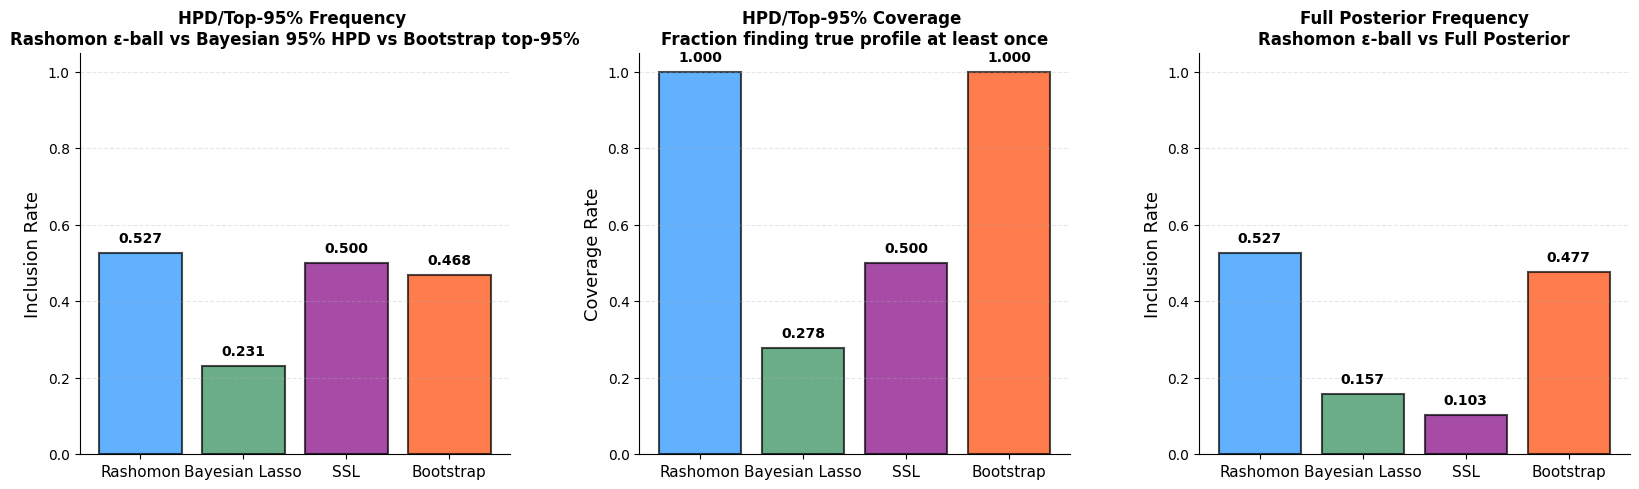

In [14]:
# Five-panel comparison plot
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

colors_methods = ['dodgerblue', 'seagreen', 'purple', 'orangered']
x_pos = np.arange(len(comparison_df))

# Panel 1: HPD/Top-K Frequency (FAIR COMPARISON)
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.bar(x_pos, comparison_df['HPD_Frequency'], color=colors_methods, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_df['Method'], rotation=0, fontsize=11)
ax1.set_ylabel('Inclusion Rate', fontsize=13)
ax1.set_title('HPD/Top-95% Frequency \nRashomon ε-ball vs Bayesian 95% HPD vs Bootstrap top-95%', 
              fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines[['right', 'top']].set_visible(False)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    if not np.isnan(height):
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 2: HPD/Top-K Binary Presence (COVERAGE)
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(x_pos, comparison_df['HPD_Presence'], color=colors_methods, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison_df['Method'], rotation=0, fontsize=11)
ax2.set_ylabel('Coverage Rate', fontsize=13)
ax2.set_title('HPD/Top-95% Coverage \nFraction finding true profile at least once', 
              fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines[['right', 'top']].set_visible(False)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    if not np.isnan(height):
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 4: Full Posterior/Sample Frequency (EXPLORATION BREADTH)
ax4 = fig.add_subplot(gs[0, 2])
bars4 = ax4.bar(x_pos, comparison_df['Full_Frequency'], color=colors_methods, alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(comparison_df['Method'], rotation=0, fontsize=11)
ax4.set_ylabel('Inclusion Rate', fontsize=13)
ax4.set_title('Full Posterior Frequency\nRashomon ε-ball vs Full Posterior', 
              fontsize=12, fontweight='bold')
ax4.set_ylim(0, 1.05)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
ax4.spines[['right', 'top']].set_visible(False)

# Add value labels
for bar in bars4:
    height = bar.get_height()
    if not np.isnan(height):
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')


plt.tight_layout()
# plt.savefig('../Figures/reff/posterior_comparison_four_panel.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Credible Interval Size Analysis

Analyze how different credible interval sizes (90%, 95%, 99%, etc.) affect:
1. Coverage: Fraction of simulations finding the true profile at least once
2. Sample size: Number of models/samples included in the region

In [15]:
# Compute coverage and sample size for different credible interval sizes
credible_levels = list(np.arange(0.05, 1, 0.05)) + [0.99]
# credible_levels = [0.5, 0.9]

# Store results
results_by_level = {
    'credible_level': [],
    'rashomon_coverage': [],
    'rashomon_mean_size': [],
    'blasso_coverage': [],
    'blasso_mean_size': [],
    'ssl_coverage': [],
    'ssl_mean_size': [],
    'bootstrap_coverage': [],
    'bootstrap_mean_size': []
}

for level in credible_levels:
    print(f"Computing for credible level {level:.0%}...")
    
    # Rashomon
    rashomon_presence_level, rashomon_coverage_level = compute_hpd_binary_presence(
        rashomon_df, true_best_profile, credible_mass=level
    )
    _, _, rashomon_size_level, rashomon_freq = compute_hpd_frequency2(
        rashomon_df, true_best_profile, credible_mass=level
    )
    
    # Bayesian Lasso
    blasso_presence_level, blasso_coverage_level = compute_hpd_binary_presence(
        blasso_df, true_best_profile, credible_mass=level
    )
    _, _, blasso_size_level, blasso_freq = compute_hpd_frequency2(
        blasso_df, true_best_profile, credible_mass=level
    )
    
    # SSL
    ssl_presence_level, ssl_coverage_level = compute_hpd_binary_presence(
        ssl_df, true_best_profile, credible_mass=level
    )
    _, _, ssl_size_level, ssl_freq = compute_hpd_frequency2(
        ssl_df, true_best_profile, credible_mass=level
    )
    
    # Bootstrap
    # bootstrap_presence_level, bootstrap_coverage_level = compute_top_k_binary_presence(
    #     bootstrap_samples_df, true_best_profile, 'penalized_loss', k_fraction=level
    # )
    # # Count samples in top-K
    # bootstrap_samples_copy = bootstrap_samples_df.copy()
    # bootstrap_samples_copy = bootstrap_samples_copy.sort_values(
    #     ['n_per_pol', 'sim_num', 'penalized_loss'], ascending=[True, True, True]
    # )
    # bootstrap_samples_copy['rank'] = bootstrap_samples_copy.groupby(['n_per_pol', 'sim_num']).cumcount()
    # total_per_sim = bootstrap_samples_copy.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='total')
    # total_per_sim['k_threshold'] = (total_per_sim['total'] * level).astype(int)
    # bootstrap_mean_size = total_per_sim['k_threshold'].mean()


    bootstrap_presence_level, bootstrap_coverage_level = compute_hpd_binary_presence(
        bootstrap_samples_df, true_best_profile, credible_mass=level
    )
    _, _, bootstrap_size_level, bootstrap_freq = compute_hpd_frequency2(
        bootstrap_samples_df, true_best_profile, credible_mass=level
    )
    
    # Store results
    results_by_level['credible_level'].append(level)
    results_by_level['rashomon_coverage'].append(rashomon_coverage_level)
    results_by_level['rashomon_mean_size'].append(rashomon_freq["hpd_size"].mean())
    results_by_level['blasso_coverage'].append(blasso_coverage_level)
    results_by_level['blasso_mean_size'].append(blasso_freq["hpd_size"].mean())
    results_by_level['ssl_coverage'].append(ssl_coverage_level)
    results_by_level['ssl_mean_size'].append(ssl_freq['hpd_size'].mean())
    # results_by_level['bootstrap_coverage'].append(bootstrap_presence_level["topk_binary_presence"].mean())
    # results_by_level['bootstrap_mean_size'].append(bootstrap_mean_size)
    results_by_level['bootstrap_coverage'].append(bootstrap_coverage_level)
    results_by_level['bootstrap_mean_size'].append(bootstrap_freq['hpd_size'].mean())

# Convert to DataFrame
credible_analysis_df = pd.DataFrame(results_by_level)
print("\nDone!")
credible_analysis_df

Computing for credible level 5%...
Computing for credible level 10%...
Computing for credible level 10%...
Computing for credible level 15%...
Computing for credible level 15%...
Computing for credible level 20%...
Computing for credible level 20%...
Computing for credible level 25%...
Computing for credible level 25%...
Computing for credible level 30%...
Computing for credible level 30%...
Computing for credible level 35%...
Computing for credible level 35%...
Computing for credible level 40%...
Computing for credible level 40%...
Computing for credible level 45%...
Computing for credible level 45%...
Computing for credible level 50%...
Computing for credible level 50%...
Computing for credible level 55%...
Computing for credible level 55%...
Computing for credible level 60%...
Computing for credible level 60%...
Computing for credible level 65%...
Computing for credible level 65%...
Computing for credible level 70%...
Computing for credible level 70%...
Computing for credible level 

,credible_level,rashomon_coverage,rashomon_mean_size,blasso_coverage,blasso_mean_size,ssl_coverage,ssl_mean_size,bootstrap_coverage,bootstrap_mean_size
0,0.05,0.69,92.51,NaN,NaN,NaN,NaN,0.91,47.38
1,0.10,0.82,193.38,NaN,NaN,NaN,NaN,0.96,95.99
2,0.15,0.85,295.61,NaN,NaN,NaN,NaN,0.98,144.92
3,0.20,0.92,397.88,NaN,NaN,NaN,NaN,0.99,193.93
4,0.25,0.94,501.04,NaN,NaN,NaN,NaN,0.99,243.01
5,0.30,0.95,603.33,NaN,NaN,NaN,NaN,0.99,292.51
6,0.35,0.96,705.65,NaN,NaN,NaN,NaN,0.99,341.97
7,0.40,0.96,807.89,NaN,NaN,NaN,NaN,1.00,391.71
8,0.45,0.96,911.13,1.000000,1.000000,NaN,NaN,1.00,441.45
9,0.50,0.96,1013.40,1.000000,1.000000,NaN,NaN,1.00,491.32


In [134]:
bootstrap_coverage_level

1.0

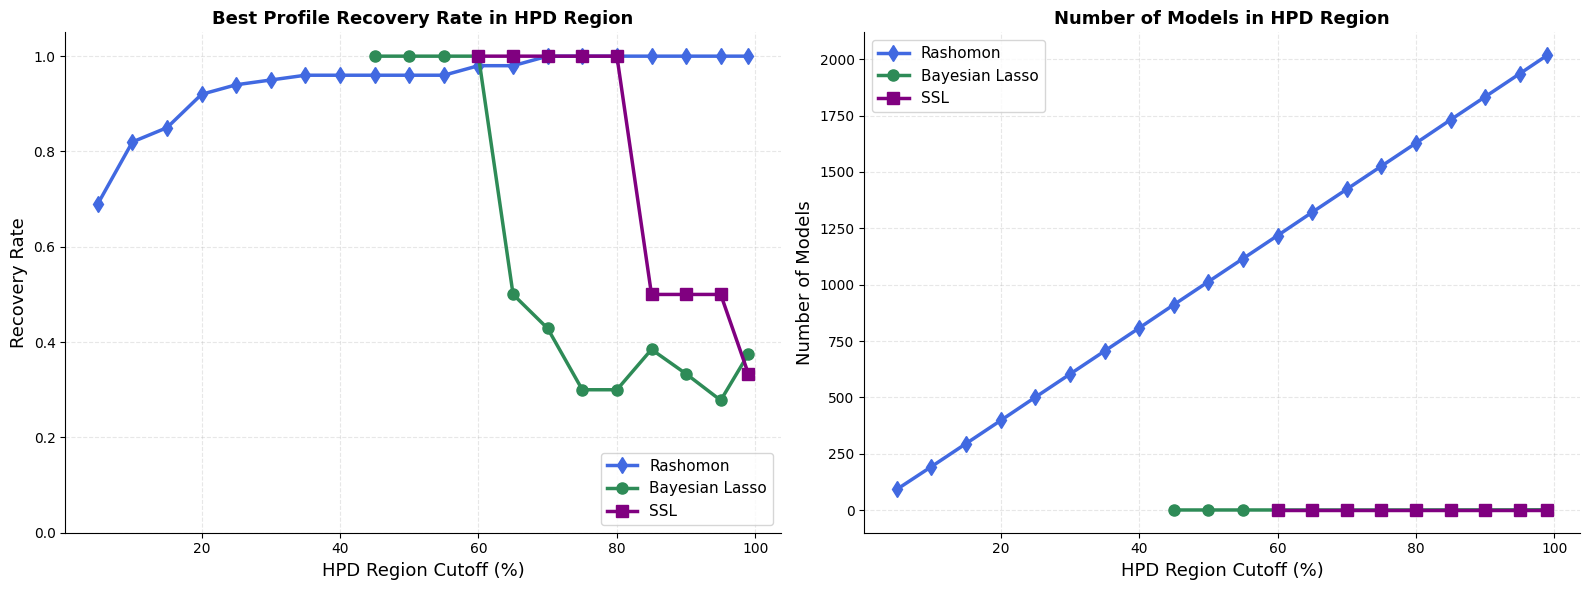

In [16]:
# Plot 1: Coverage vs Credible Level
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Coverage (fraction finding true profile at least once)
ax1 = axes[0]
ax1.plot(credible_analysis_df['credible_level'] * 100, 
         credible_analysis_df['rashomon_coverage'], 
         marker='d', markersize=8, linewidth=2.5, label='Rashomon', color='royalblue')
ax1.plot(credible_analysis_df['credible_level'] * 100, 
         credible_analysis_df['blasso_coverage'], 
         marker='o', markersize=8, linewidth=2.5, label='Bayesian Lasso', color='seagreen')
ax1.plot(credible_analysis_df['credible_level'] * 100, 
         credible_analysis_df['ssl_coverage'], 
         marker='s', markersize=8, linewidth=2.5, label='SSL', color='purple')
# ax1.plot(credible_analysis_df['credible_level'] * 100, 
#          credible_analysis_df['bootstrap_coverage'], 
#          marker='^', markersize=8, linewidth=2.5, label='Bootstrap', color='orangered')

ax1.set_xlabel('HPD Region Cutoff (%)', fontsize=13)
ax1.set_ylabel('Recovery Rate', fontsize=13)
ax1.set_title('Best Profile Recovery Rate in HPD Region', 
              fontsize=13, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(alpha=0.3, linestyle='--')
ax1.spines[['right', 'top']].set_visible(False)

# Plot 2: Mean sample size vs Credible Level
ax2 = axes[1]
ax2.plot(credible_analysis_df['credible_level'] * 100, 
         credible_analysis_df['rashomon_mean_size'], 
         marker='d', markersize=8, linewidth=2.5, label='Rashomon', color='royalblue')
ax2.plot(credible_analysis_df['credible_level'] * 100, 
         credible_analysis_df['blasso_mean_size'], 
         marker='o', markersize=8, linewidth=2.5, label='Bayesian Lasso', color='seagreen')
ax2.plot(credible_analysis_df['credible_level'] * 100, 
         credible_analysis_df['ssl_mean_size'], 
         marker='s', markersize=8, linewidth=2.5, label='SSL', color='purple')
# ax2.plot(credible_analysis_df['credible_level'] * 100, 
#          credible_analysis_df['bootstrap_mean_size'], 
#          marker='^', markersize=8, linewidth=2.5, label='Bootstrap', color='orangered')

ax2.set_xlabel('HPD Region Cutoff (%)', fontsize=13)
ax2.set_ylabel('Number of Models', fontsize=13)
ax2.set_title('Number of Models in HPD Region', 
              fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(alpha=0.3, linestyle='--')
ax2.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
# plt.savefig('../Figures/reff/credible_interval_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
np.max(rashomon_df["posterior_weight"])

0.016973712548092754

In [21]:
def test(e, pmax):
    e_norm = e / pmax
    print(e_norm)
    return pmax * (1 +e_norm), pmax*(1+e)


print(test(0.1, 0.5))
print(test(0.1, 0.9))

0.2
(0.6, 0.55)
0.11111111111111112
(1.0, 0.9900000000000001)
